<a href="https://colab.research.google.com/github/FOFM030711/Caminata-aleatoria-1D/blob/main/METROPOLIS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**METODO DE MONTE CARLO VIA CADENA DE MARKOV**



---

Algoritmo de Metrópolis

---

**Paso 1** Inicializar $X_0$, $t=0$



**Paso 2** Repetir  

                  

Generar un candidato  $Y ∼ q (. \ lX_t)$



Generar $U∼U(0,1)$



Si $U \leq \alpha (X_t,Y)$, tomar $X_{t+1}=Y$

otro casi, tomar $X_{t+1}=X_t$



Incrementar $t$

* Ejemplo: obtener una muestra de $$π(x) ∝ e^{\frac{-x^t}{2}}(1+0.3sen(5x))$$



In [9]:
#importamos librerias
import numpy as np
import matplotlib.pyplot as plt


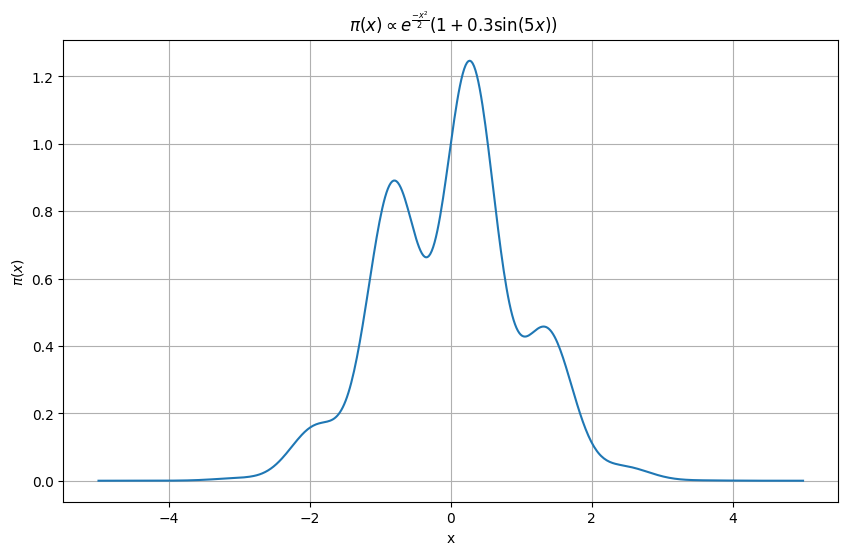

In [10]:

#DEFINIRT LA FUNCION
def pi_x(x):

    return np.exp(-x**2 / 2) * (1 + 0.3 * np.sin(5 * x))


x = np.linspace(-5, 5, 500)


y = pi_x(x)


plt.figure(figsize=(10, 6))
plt.plot(x, y)
plt.title(r' $\pi(x) \propto e^{\frac{-x^2}{2}}(1+0.3\sin(5x))$')
plt.xlabel('x')
plt.ylabel(r'$\pi(x)$')
plt.grid(True)
plt.show()

Generar el candidato $$X´ = X_0+Ε , Ε\sim N(0,σ^2 )$$



Aceptar con probabilidad α

$$α = min(1, \frac{π(X´)}{π(X)})$$

*  Si $X_0=0$, $X´=1.2$
$$α = min(1, \frac{π(2)}{π(0)})=0.44$$
Generar $U\sim U(0,1)$ y si $U\leq α$ aceptas $X´$

In [11]:
X_0=0
X_p=1.2
sigma=0.1
alpha=min(1,pi_x(X_p)/pi_x(X_0))
print(alpha)

0.44595041873041974


In [12]:
def metropolis(x_0, sigma, pi_x, n_steps):
    x = [x_0]
    for _ in range(n_steps):
        x_prime = x[-1] + np.random.normal(0, sigma)
        alpha = min(1, pi_x(x_prime) / pi_x(x[-1]))
        if np.random.uniform() <= alpha:
            x.append(x_prime)
        else:
            x.append(x[-1])
    return x

In [13]:
metropolis(X_0,sigma,pi_x,1000)
#

[0,
 -0.034875025678483045,
 -0.06705683629071016,
 -0.06589032123450206,
 -0.15520890233548737,
 -0.06453490076154364,
 0.02778302651247269,
 -0.1918474188797997,
 -0.07346581962708279,
 -0.07837682308337843,
 -0.21396692297190592,
 -0.12402558138546359,
 -0.2473900993251234,
 -0.16255101728654509,
 0.007902331176083244,
 -0.06123380270328352,
 -0.06233107250072983,
 0.10025611103670859,
 0.0803669090083515,
 -0.013326024791076044,
 0.036244647784865566,
 0.0023277356044793737,
 0.05629412292100161,
 -0.06695868174113895,
 -0.19110491500875962,
 -0.19567620789899035,
 -0.28560196264412996,
 -0.34468279010939873,
 -0.2512051531768884,
 -0.22474635991244468,
 -0.1806737527137558,
 -0.3468955671016343,
 -0.32106528177767063,
 -0.31361981736176153,
 -0.23475577577892842,
 -0.2970926527964683,
 -0.19512190706816557,
 -0.1924837578503932,
 -0.01321116119545343,
 0.15470220015912178,
 0.09026766539304291,
 0.23189465883985116,
 0.28085993757200467,
 0.18953960758506216,
 0.1550249876904128,


(array([ 1.,  2.,  0.,  2.,  0.,  0.,  2.,  0.,  2.,  1.,  1.,  0.,  3.,
         0.,  1.,  2.,  0.,  5.,  2.,  0.,  0.,  0.,  1.,  1.,  0.,  0.,
         0.,  1.,  1.,  1.,  2.,  2.,  2.,  6.,  6.,  7., 18., 16., 15.,
        20., 13., 15., 25., 24., 22., 33., 23., 23., 22., 24., 21., 14.,
        23., 20., 13., 17., 10., 14., 17., 11.,  7., 10.,  8., 16., 15.,
        23., 15., 14., 15., 15., 17., 15., 11., 13., 17., 17., 27., 28.,
        23., 27., 27., 14., 17., 14., 13., 10.,  9.,  5.,  6.,  8.,  5.,
        13.,  6.,  6.,  0.,  2.,  1.,  2.,  1.,  2.]),
 array([-2.12389589e+00, -2.09734322e+00, -2.07079054e+00, -2.04423787e+00,
        -2.01768520e+00, -1.99113252e+00, -1.96457985e+00, -1.93802718e+00,
        -1.91147450e+00, -1.88492183e+00, -1.85836916e+00, -1.83181648e+00,
        -1.80526381e+00, -1.77871114e+00, -1.75215847e+00, -1.72560579e+00,
        -1.69905312e+00, -1.67250045e+00, -1.64594777e+00, -1.61939510e+00,
        -1.59284243e+00, -1.56628975e+00, -1.53973708e

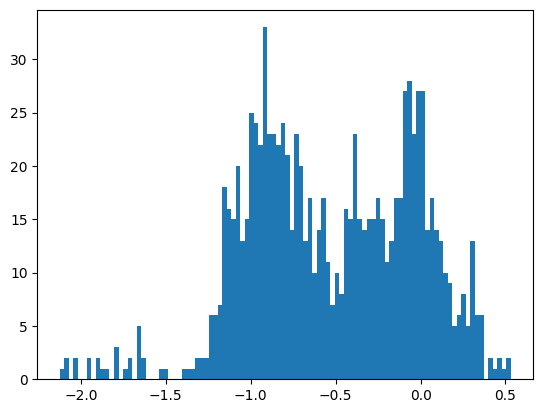

In [14]:
plt.hist(metropolis(X_0,sigma,pi_x,1000),bins=100)